# 12장 실습 — 데이터: 무엇을 얼마나 모을 것인가

**대응 이론** 12장 「데이터를 모으는 일」 · **실행 등급 A** (CPU / Colab 무료 티어, 전체 약 2분)

VLA 프로젝트에서 가장 자주 나오는 질문은 "시연을 몇 편 모아야 하나요"다. 이 질문은 거의 항상 잘못된 질문이다.

이 노트북에서 잴 것은 네 가지다. 같은 예산으로 **어디서** 모으느냐가 **몇 개** 모으느냐를 이기는지, 개수를 늘리면 어디서 멈추는지, 남의 로봇 데이터가 내 데이터를 대신할 수 있는지, 그리고 여러 사람이 모은 데이터를 합칠 때 무슨 일이 생기는지.

앞 장들과 달리 여기서는 이미지를 쓰지 않는다. 데이터의 성질만 보려면 지각을 고정해야 한다 — 5장에서 배운 실험 격리의 원칙이다. 블록 두 개의 좌표와 어느 색을 집으라는 지시가 6개 숫자로 들어가고, 7차원 액션이 나온다.

1. 같은 예산, 다른 범위
2. 개수를 늘리면 어디서 멈추는가
3. 결정적 비교 — 좁게 1600편 vs 넓게 100편
4. 남의 로봇 데이터를 섞으면
5. 두 사람이 모으면

In [1]:
%matplotlib inline
import os, math, time
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
import koreanize_matplotlib

torch.manual_seed(0); np.random.seed(0)
torch.set_num_threads(os.cpu_count() or 2)

RED, GREY, PINK = "#e32c24", "#c8c8c8", "#f6c9c6"
print("torch", torch.__version__)

torch 2.9.1


## 1. 같은 예산, 다른 범위

과제는 4장의 토이를 좌표로 줄인 것이다. 책상에 블록 두 개가 놓이고, 지시는 둘 중 하나를 가리킨다.

중요한 것은 **수집 분포와 배포 분포를 따로 둔다**는 점이다. 실전에서 이 둘은 늘 다르다. 연구실 책상 가운데에서 모은 데이터로 현장에서 아무 데나 놓인 물건을 집어야 한다.

- **배포 분포(평가)** — 블록이 ±0.8 어디에나, 두 색 모두 지시
- **수집 분포(학습)** — 범위와 색을 우리가 고른다

같은 200편 예산을 네 가지 방식으로 쓴다.

In [2]:
AD = 7

def sample(n, seed, span=0.8, colors=(0, 1)):
    # span: 블록이 놓이는 범위,  colors: 지시에 등장하는 색
    r = np.random.default_rng(seed)
    p = r.uniform(-span, span, (n, 2, 2)).astype(np.float32)
    t = np.array([colors[int(r.integers(len(colors)))] for _ in range(n)])
    x = np.concatenate([p.reshape(n, 4), np.eye(2, dtype=np.float32)[t]], 1)
    c = p[np.arange(n), t]; d = np.hypot(c[:, 0], c[:, 1])
    a = np.stack([c[:, 0], c[:, 1], -0.15 - 0.5 * d, np.zeros(n), np.zeros(n),
                  np.arctan2(c[:, 1], c[:, 0]) / np.pi, np.where(d < .4, 1, -1)], 1).astype(np.float32)
    return torch.tensor(x), torch.tensor(np.clip(a, -1, 1))

TEST = sample(2048, 999)          # 배포 분포는 언제나 이것

class M(nn.Module):
    def __init__(s, h=128):
        super().__init__()
        s.f = nn.Sequential(nn.Linear(6, h), nn.GELU(), nn.Linear(h, h), nn.GELU(), nn.Linear(h, AD))
    def forward(s, x): return s.f(x)

def fit(X, Y, steps=1200, lr=3e-3, bs=64, seed=0, tests=None):
    torch.manual_seed(seed); m = M()
    opt = torch.optim.AdamW(m.parameters(), lr=lr, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.OneCycleLR(opt, lr, steps, pct_start=.15)
    g = torch.Generator().manual_seed(7)
    for i in range(steps):
        idx = torch.randint(0, len(X), (min(bs, len(X)),), generator=g)
        loss = F.smooth_l1_loss(m(X[idx]), Y[idx], beta=.02)
        opt.zero_grad(); loss.backward(); opt.step(); sch.step()
    out = []
    for T in (tests or [TEST]):
        with torch.no_grad(): p = m(T[0])
        ang = torch.rad2deg(torch.acos(F.cosine_similarity(p[:, :2], T[1][:, :2], dim=-1).clamp(-1, 1)))
        out.append(((p - T[1]).abs().mean().item(), ang.mean().item()))
    return out

print(f"{'수집 방식':<30}{'MAE':>10}{'각도오차':>11}")
print("-" * 51)
for nm, kw in [("좁은 범위(±0.3), 한 색만", dict(span=0.3, colors=(0,))),
               ("좁은 범위(±0.3), 두 색",   dict(span=0.3, colors=(0, 1))),
               ("넓은 범위(±0.8), 한 색만", dict(span=0.8, colors=(0,))),
               ("넓은 범위(±0.8), 두 색",   dict(span=0.8, colors=(0, 1)))]:
    X, Y = sample(200, 1, **kw)
    (mae, a), = fit(X, Y)
    print(f"{nm:<30}{mae:10.4f}{a:10.1f}°")

수집 방식                                MAE       각도오차
---------------------------------------------------
좁은 범위(±0.3), 한 색만                 0.4399      47.6°
좁은 범위(±0.3), 두 색                  0.3541       3.0°
넓은 범위(±0.8), 한 색만                 0.2136      47.1°
넓은 범위(±0.8), 두 색                  0.0934       0.6°


좁은 범위(±0.3), 한 색만                 0.4399      47.6°


좁은 범위(±0.3), 두 색                  0.3541       3.0°


넓은 범위(±0.8), 한 색만                 0.2136      47.1°


넓은 범위(±0.8), 두 색                  0.0934       0.6°


## 2. 개수를 늘리면 어디서 멈추는가

수집 방식을 가장 좋은 것(넓은 범위·두 색)으로 고정하고 개수만 늘린다.

시연 수             MAE       각도오차
-------------------------------
25            0.1688       3.9°
50            0.1534       2.5°
100           0.1097       1.0°
200           0.0934       0.6°
400           0.0912       0.5°
800           0.0904       0.4°


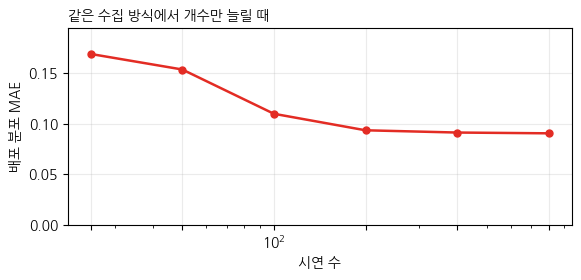

50            0.1529       2.6°


100           0.1097       1.0°


200           0.0934       0.6°


400           0.0912       0.5°


800           0.0904       0.4°


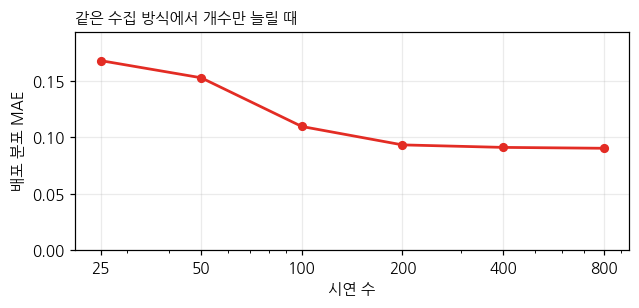

In [3]:
ns = [25, 50, 100, 200, 400, 800]
maes = []
print(f"{'시연 수':<10}{'MAE':>10}{'각도오차':>11}")
print("-" * 31)
for n in ns:
    X, Y = sample(n, 1)
    (mae, a), = fit(X, Y); maes.append(mae)
    print(f"{n:<10}{mae:10.4f}{a:10.1f}°")

fig, ax = plt.subplots(figsize=(6, 2.9))
ax.plot(ns, maes, "o-", color=RED, lw=1.8, ms=5)
ax.set_xscale("log"); ax.set_xticks(ns)
ax.set_xlabel("시연 수"); ax.set_ylabel("배포 분포 MAE")
ax.set_ylim(0, max(maes) * 1.15)
ax.grid(alpha=.25); ax.set_title("같은 수집 방식에서 개수만 늘릴 때", loc="left", fontsize=10)
plt.tight_layout(); plt.show()

## 3. 결정적 비교

앞의 두 절을 하나의 표로 합친다. 좁은 범위에서 **16배** 많이 모은 것과, 넓은 범위에서 조금 모은 것을 맞붙인다.

In [4]:
X, Y = sample(1600, 1, span=0.3); (m_narrow, a_n), = fit(X, Y)
X, Y = sample(100, 1, span=0.8);  (m_wide, a_w), = fit(X, Y)
print(f"좁은 범위(±0.3)에서 1600편 : MAE {m_narrow:.4f}   각도오차 {a_n:5.1f}°")
print(f"넓은 범위(±0.8)에서  100편 : MAE {m_wide:.4f}   각도오차 {a_w:5.1f}°")
print(f"\n데이터 {1600/100:.0f}배 적은 쪽이 MAE {m_narrow/m_wide:.1f}배 낫다.")

좁은 범위(±0.3)에서 1600편 : MAE 0.3321   각도오차   2.6°
넓은 범위(±0.8)에서  100편 : MAE 0.1097   각도오차   1.0°

데이터 16배 적은 쪽이 MAE 3.0배 낫다.


## 4. 남의 로봇 데이터를 섞으면

Open X-Embodiment 이후로 표준 답은 "남의 데이터로 사전학습하고 내 데이터로 파인튜닝하라"다. 그 효과가 정확히 무엇인지 본다.

남의 로봇은 같은 과제를 하지만 규약이 조금 다르다 — 이동 크기가 0.7배로 스케일되고 손목 각도에 상수 오프셋이 있다. 실제 데이터셋 사이의 차이가 딱 이런 모양이다.

내 로봇 시연은 40편으로 고정하고 남의 데이터만 늘린다.

In [5]:
def other(n, seed):
    X, Y = sample(n, seed, span=0.8)
    Y = Y.clone(); Y[:, 0] *= 0.7; Y[:, 1] *= 0.7; Y[:, 5] += 0.25   # 규약이 어긋난다
    return X, Y

Xin, Yin = sample(40, 1)
print("내 로봇 시연 40편 + 남의 로봇 데이터")
print(f"{'남의 데이터':<14}{'MAE':>10}{'각도오차':>11}")
print("-" * 35)
for n in (0, 40, 160, 640, 2560):
    if n == 0: X, Y = Xin, Yin
    else:
        Xo, Yo = other(n, 33); X = torch.cat([Xin, Xo]); Y = torch.cat([Yin, Yo])
    (mae, a), = fit(X, Y)
    print(f"{n:<14}{mae:10.4f}{a:10.1f}°")

print("\n(대조) 남의 데이터 없이 내 시연만 같은 총량까지 늘릴 때")
print(f"{'내 시연':<14}{'MAE':>10}{'각도오차':>11}")
print("-" * 35)
for n in (40, 80, 200, 680, 2600):
    X, Y = sample(n, 1)
    (mae, a), = fit(X, Y)
    print(f"{n:<14}{mae:10.4f}{a:10.1f}°")

내 로봇 시연 40편 + 남의 로봇 데이터
남의 데이터               MAE       각도오차
-----------------------------------
0                 0.1564       2.0°
40                0.1412       4.5°
160               0.1427       1.4°
640               0.1415       0.6°
2560              0.1419       0.6°

(대조) 남의 데이터 없이 내 시연만 같은 총량까지 늘릴 때
내 시연                 MAE       각도오차
-----------------------------------
40                0.1564       2.0°
80                0.1051       1.1°
200               0.0934       0.6°
680               0.0913       0.5°
2600              0.0885       0.4°


0                 0.1563       2.0°


40                0.1412       4.5°


160               0.1427       1.4°


640               0.1415       0.6°


...

40                0.1563       2.0°


80                0.1051       1.1°


200               0.0934       0.6°


680               0.0913       0.5°


2600              0.0885       0.4°


## 5. 두 사람이 모으면

마지막 함정은 데이터의 양도 범위도 아니다. 같은 과제를 두 사람이 서로 다른 습관으로 시연하면 무슨 일이 생기는가.

작업자 B 는 손목을 조금 더 틀고 하강을 얕게 한다. 둘 다 과제를 성공시킨다 — 틀린 시연이 아니다. 총 200편을 고정하고 B 의 비율만 바꾼다. 평가는 A 의 규약과 B 의 규약 양쪽에 대해 각각 한다.

B 비율          A 기준 MAE    B 기준 MAE      둘 중 나은 쪽
------------------------------------------------
0%              0.0934      0.1582        0.0934
10%             0.0965      0.1552        0.0965
25%             0.1009      0.1451        0.1009
50%             0.1279      0.1247        0.1247
75%             0.1513      0.0999        0.0999
100%            0.1602      0.0920        0.0920


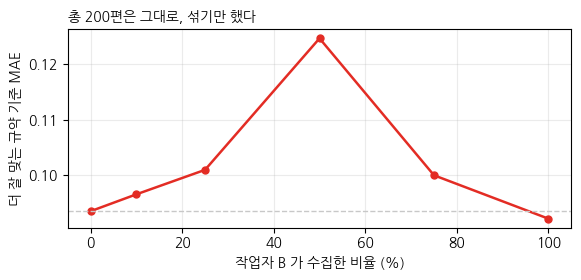

10%             0.0965      0.1552        0.0965


25%             0.1009      0.1451        0.1009


50%             0.1279      0.1248        0.1248


75%             0.1513      0.0999        0.0999


100%            0.1602      0.0920        0.0920


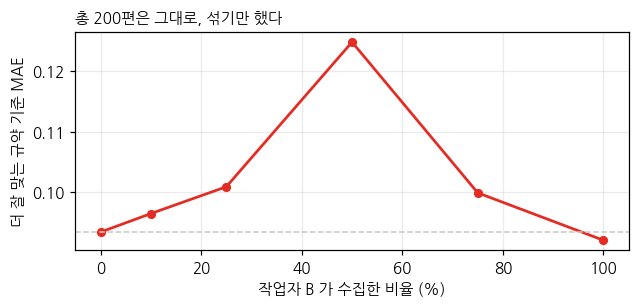

In [6]:
def habit_B(Y):
    Y = Y.clone(); Y[:, 5] += 0.4; Y[:, 2] *= 0.5; return Y

TA = TEST; TB = (TEST[0], habit_B(TEST[1]))
fr, best = [], []
print(f"{'B 비율':<10}{'A 기준 MAE':>12}{'B 기준 MAE':>12}{'둘 중 나은 쪽':>14}")
print("-" * 48)
for frac in (0.0, 0.1, 0.25, 0.5, 0.75, 1.0):
    X, Y = sample(200, 1); k = int(len(X) * frac)
    Y = Y.clone(); Y[:k] = habit_B(Y[:k])
    (ma, _), (mb, _) = fit(X, Y, tests=[TA, TB])
    fr.append(frac); best.append(min(ma, mb))
    print(f"{frac:<10.0%}{ma:12.4f}{mb:12.4f}{min(ma, mb):14.4f}")

fig, ax = plt.subplots(figsize=(6, 2.9))
ax.plot([f * 100 for f in fr], best, "o-", color=RED, lw=1.8, ms=5)
ax.axhline(best[0], color=GREY, ls="--", lw=1)
ax.set_xlabel("작업자 B 가 수집한 비율 (%)"); ax.set_ylabel("더 잘 맞는 규약 기준 MAE")
ax.grid(alpha=.25); ax.set_title("총 200편은 그대로, 섞기만 했다", loc="left", fontsize=10)
plt.tight_layout(); plt.show()

### 다음 장으로

다음 장에서는 이렇게 모은 데이터로 사전학습된 모델을 파인튜닝할 때 무엇이 어긋나는지 본다. 데이터가 옳아도 파이프라인이 어긋나면 결과는 똑같이 나쁘다.